## 1. Import Required Libraries

In [1]:
# ================================
# Import Libraries
# ================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.15.0


## 2. Load Dataset

In [2]:
# ================================
# Dataset Paths
# ================================

train_path = "chest_xray/train"
val_path = "chest_xray/val"
test_path = "chest_xray/test"

img_size = 224
batch_size = 32

## 3. Data Preprocessing & Augmentation

In [3]:
# ================================
# Data Preprocessing
# ================================

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & test (only rescale)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary"
)

val_data = test_datagen.flow_from_directory(
    val_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 17 images belonging to 2 classes.
Found 626 images belonging to 2 classes.


## 4. Visualize Sample Images

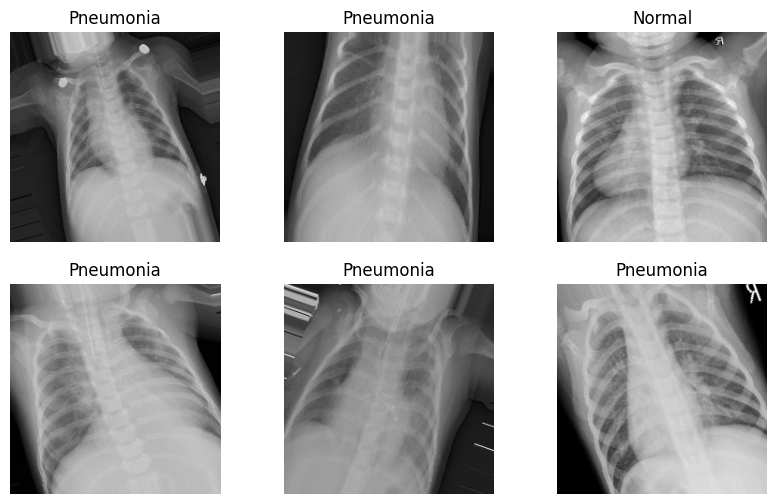

In [4]:
# ================================
# Show Training Images
# ================================

images, labels = next(train_data)

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i]==1 else "Normal")
    plt.axis("off")

plt.show()

## 5. Build Deep Learning Model (Transfer Learning - MobileNetV2)

In [5]:
# ================================
# Load Pretrained Model
# ================================

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2422081 (9.24 MB)
Trainable params: 1640

## 6. Compile Model

In [6]:
# ================================
# Compile Model
# ================================

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 7. Train Model

In [7]:
# ================================
# Train Model
# ================================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30


163/163 [==============================] - 200s 1s/step - loss: 0.3923 - accuracy: 0.8263 - val_loss: 0.4709 - val_accuracy: 0.7647
Epoch 2/30
163/163 [==============================] - 167s 1s/step - loss: 0.2225 - accuracy: 0.9082 - val_loss: 0.4113 - val_accuracy: 0.7647
Epoch 3/30
163/163 [==============================] - 166s 1s/step - loss: 0.1876 - accuracy: 0.9220 - val_loss: 0.4115 - val_accuracy: 0.7647
Epoch 4/30
163/163 [==============================] - 173s 1s/step - loss: 0.1713 - accuracy: 0.9314 - val_loss: 0.3923 - val_accuracy: 0.7647
Epoch 5/30
163/163 [==============================] - 187s 1s/step - loss: 0.1553 - accuracy: 0.9390 - val_loss: 0.3613 - val_accuracy: 0.8235
Epoch 6/30
163/163 [==============================] - 177s 1s/step - loss: 0.1432 - accuracy: 0.9446 - val_loss: 0.3870 - val_accuracy: 0.7647
Epoch 7/30
163/163 [==============================] - 180s 1s/step - loss: 0.1428 - accuracy: 0.9436 - val_loss: 0.3487 - val_accuracy: 0.82

## 8. Plot Training Accuracy & Loss

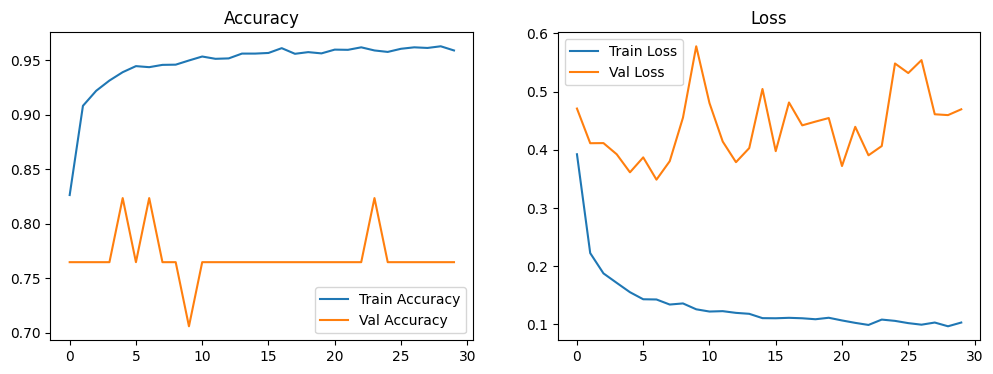

In [8]:
# ================================
# Plot Performance
# ================================

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()

## 9. Evaluate Model

In [9]:
# ================================
# Test Accuracy
# ================================

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 [==============================] - 11s 552ms/step - loss: 0.2921 - accuracy: 0.8882
Test Accuracy: 0.8881788849830627


## 10. Save Model

In [10]:
# ================================
# Save Model
# ================================

model.save("pneumonia_model.h5")
print("Model Saved")

C:\Users\yoges\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model Saved


## 11. Predict New X-ray Image

In [15]:
# ================================
# Predict New Image
# ================================

from tensorflow.keras.preprocessing import image

img_path = "person1_virus_11.jpeg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Pneumonia Detected")
else:
    print("Normal")

1/1 [==============================] - 1s 1s/step
Pneumonia Detected
